# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 11/07/23, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 2 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.
-   Problem 3 (5750 only) asks you to add a CO<sub>2</sub> constraint to
    the capacity expansion problem and identify changes in the resulting
    solution.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\ajvil\Downloads\hw4-team-1-1`


In [3]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 50/60 Points)

### Problem 1 (20 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-ha-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

**In this problem**:

-   Formulate a linear program for this resource allocation problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations). **Tip: Make sure that all of your constraints are
    linear**.
-   Implement the program in `JuMP.jl` and find the solution. How many
    ha should the farmer dedicate to each crop and with what pesticide
    application rate(s)? How much profit will the farmer expect to make?
-   The farmer has an opportunity to buy an extra 10 ha of land. How
    much extra profit would this land be worth to the farmer? Discuss
    why this value makes sense and whether you would recommend the
    farmer should make the purchase.

Step 1: Decision Variables

- $S_0, S_1, S_2$: Area (ha) allocated to soybeans with 0, 1, and 2 kg/ha application rates, respectively.
- $W_0, W_1, W_2$: Area (ha) allocated to wheat with 0, 1, and 2 kg/ha application rates, respectively.
- $C_0, C_1, C_2$: Area (ha) allocated to corn with 0, 1, and 2 kg/ha application rates, respectively.
- $r_s, r_w, r_c$: application rate of pesticide (kg/ha) applied to the field for soybean, wheat, and corn, respectively. 

Step 2: Objective Functions 

The farmer is interested in maximizing their profit given the environmental authority constraints. The total profit the farmer will earn from their operation can be expressed as:

Profit = Total Revenue - Total Production Cost - Total Pesticide Cost

Now, breaking down each term individually:

Revenue = Selling Price ($\frac{\$}{kg}$) * Crop Yield($\frac{kg}{ha}$) * Area $(ha)$, where yield depends on the pesticide rate.
- Revenue $=
    0.36(2900S_0 + 3800S_1 + 4400S_2) + 
    0.27(3500W_0 + 4100W_1 + 4200W_2) + 
    0.22(5900C_0 + 6700C_1 + 7900C_2)$

Production Cost = Production cost per hectacre ($\frac{\$}{ha-yr}$)  * Area $(ha)$
- Production Cost $=
     350(S_0 + S_1 + S_2) + 
     280(W_0 + W_1 + W_2) + 
     390(C_0 + C_1 + C_2)$

Pesticide Cost = 70($\frac{\$}{kg-ha}$) * Application Rate($\frac{kg}{ha}$) * Area $(ha)$
- Pesticide Cost $= 70(S_1 + 2S_2 + W_1 + 2W_2 + C_1 + 2C_2)$
- There are no $S_0, W_0, and C_0$ becuase it indicates 

Now, putting this all together, we obtain the objective function:

$max$ $Z$ =  $
    0.36(2900S_0 + 3800S_1 + 4400S_2) + 
    0.27(3500W_0 + 4100W_1 + 4200W_2) + 
    0.22(5900C_0 + 6700C_1 + 7900C_2) -
    (350(S_0 + S_1 + S_2) + 
     280(W_0 + W_1 + W_2) + 
     390(C_0 + C_1 + C_2)) -
    70(S_1 + 2S_2 + W_1 + 2W_2 + C_1 + 2C_2))$

Step 3: Constraints 
- $r_s \leq 0.8\frac{kg}{ha}$ (pesticide application limits)
- $r_w \leq 0.7\frac{kg}{ha}$
- $r_c \leq 0.6\frac{kg}{ha}$
- $S_0 + S_1 + S_2 + W_0 + W_1 + W_2 + C_0 + C_1 + C_2 \leq 130$ (total area constraint)
- $2900S_0 + 3800S_1 + 4400S_2 <= 250000$
- $3500W_0 + 4100W_1 + 4200W_2 <= 250000$
- $5900C_0 + 6700C_1 + 7900C_2 <= 250000$

- $S_0, S_1, S_2, W_0, W_1, W_2, C_0, C_1, C_2 \geq 0$ (non-negativity constraint)

In [16]:
using JuMP, HiGHS

# Define the model
model = Model(HiGHS.Optimizer)

# Decision variables: Area for different pesticide application rates
@variable(model, S[0:2] >= 0)  # Soybeans
@variable(model, W[0:2] >= 0)  # Wheat
@variable(model, C[0:2] >= 0)  # Corn

# Objective function: Maximize profit
@objective(model, Max, 
    0.36 * (2900 * S[0] + 3800 * S[1] + 4400 * S[2]) + 
    0.27 * (3500 * W[0] + 4100 * W[1] + 4200 * W[2]) + 
    0.22 * (5900 * C[0] + 6700 * C[1] + 7900 * C[2]) -
    (350 * (S[0] + S[1] + S[2]) + 
     280 * (W[0] + W[1] + W[2]) + 
     390 * (C[0] + C[1] + C[2])) -
    70 * (1 * S[1] + 2 * S[2] + 1 * W[1] + 2 * W[2] + 1 * C[1] + 2 * C[2]))

# Constraints
@constraint(model, S[0] + S[1] + S[2] + W[0] + W[1] + W[2] + C[0] + C[1] + C[2] <= 130)

@constraint(model, 2900 * S[0] + 3800 * S[1] + 4400 * S[2] <= 250_000)
@constraint(model, 3500 * W[0] + 4100 * W[1] + 4200 * W[2] <= 250_000)
@constraint(model, 5900 * C[0] + 6700 * C[1] + 7900 * C[2] <= 250_000)

@constraint(model, rs, (S[0] + 2*S[1]) <= 0.8 * (S[0] + S[1] + S[2]))
@constraint(model, rw, (W[0] + 2*W[1]) <= 0.7 * (W[0] + W[1] + W[2]))
@constraint(model, rc, (C[0] + 2*C[1]) <= 0.6 * (C[0] + C[1] + C[2]))


# Solve the model
optimize!(model)

# Loop and print the results
for i in 0:2
    println("Optimal area for soybeans with ", i, " kg/ha: ", value(S[i]))
    println("Optimal area for wheat with ", i, " kg/ha: ", value(W[i]))
    println("Optimal area for corn with ", i, " kg/ha: ", value(C[i]))
end

# Get the optimal profit
profit = objective_value(model)
println("Maximum Profit: \$", profit)

Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.6045300239e+02 Ph1: 7(19.976); Du: 9(160.453) 0s
          4     1.3066894102e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 4
Objective value     :  1.3066894102e+05
HiGHS run time      :          0.01
Optimal area for soybeans with 0 kg/ha: 0.0
Optimal area for wheat with 0 kg/ha: 0.0
Optimal area for corn with 0 kg/ha: 0.0
Optimal area for soybeans with 1 kg/ha: 0.0
Optimal area for wheat with 1 kg/ha: 14.537686996547752
Optimal area for co

In [19]:
# Define the model
model = Model(HiGHS.Optimizer)

# Decision variables
@variable(model, S[0:2] >= 0)  # Soybeans
@variable(model, W[0:2] >= 0)  # Wheat
@variable(model, C[0:2] >= 0)  # Corn

# Objective function: Maximize profit
@objective(model, Max, 
    0.36 * (2900 * S[0] + 3800 * S[1] + 4400 * S[2]) + 
    0.27 * (3500 * W[0] + 4100 * W[1] + 4200 * W[2]) + 
    0.22 * (5900 * C[0] + 6700 * C[1] + 7900 * C[2]) -
    (350 * (S[0] + S[1] + S[2]) + 
     280 * (W[0] + W[1] + W[2]) + 
     390 * (C[0] + C[1] + C[2])) -
    70 * (1 * S[1] + 2 * S[2] + 1 * W[1] + 2 * W[2] + 1 * C[1] + 2 * C[2]))

# Constraints
total_land_constraint = @constraint(model, 
    S[0] + S[1] + S[2] + W[0] + W[1] + W[2] + C[0] + C[1] + C[2] <= 140)

@constraint(model, 2900 * S[0] + 3800 * S[1] + 4400 * S[2] <= 250_000)
@constraint(model, 3500 * W[0] + 4100 * W[1] + 4200 * W[2] <= 250_000)
@constraint(model, 5900 * C[0] + 6700 * C[1] + 7900 * C[2] <= 250_000)

@constraint(model, rs, (S[0] + 2*S[1]) <= 0.8 * (S[0] + S[1] + S[2]))
@constraint(model, rw, (W[0] + 2*W[1]) <= 0.7 * (W[0] + W[1] + W[2]))
@constraint(model, rc, (C[0] + 2*C[1]) <= 0.6 * (C[0] + C[1] + C[2]))

# Solve the model
optimize!(model)

# Loop and print the results
for i in 0:2
    println("Optimal area for soybeans with ", i, " kg/ha: ", value(S[i]))
    println("Optimal area for wheat with ", i, " kg/ha: ", value(W[i]))
    println("Optimal area for corn with ", i, " kg/ha: ", value(C[i]))
end

# Get the optimal profit
profit = objective_value(model)
println("Maximum Profit: \$", profit)

# Get the shadow price (dual value) for the total land constraint
shadow_price = dual(total_land_constraint)
println("Shadow price (value per extra hectare): \$", shadow_price)

# Calculate the increase in profit from 10 extra hectares
extra_profit = 10 * shadow_price
println("Expected increase in profit with 10 extra hectares: \$", extra_profit)

Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.6045300239e+02 Ph1: 7(19.976); Du: 9(160.453) 0s
          4     1.3795944102e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 4
Objective value     :  1.3795944102e+05
HiGHS run time      :          0.00
Optimal area for soybeans with 0 kg/ha: 0.0
Optimal area for wheat with 0 kg/ha: 0.0
Optimal area for corn with 0 kg/ha: 0.0
Optimal area for soybeans with 1 kg/ha: 0.0
Optimal area for wheat with 1 kg/ha: 18.037686996547755
Optimal area for co

A negative shadow price suggests that the current land allocation is already optimal, and adding more land introduces inefficiencies—such as higher production or pesticide costs—that outweigh the revenue gained.

In other words, the farmer is already operating at an efficient scale given the available resources (pesticide, crop yields, demand constraints). Increasing the land will force them to plant more crops, but the extra revenue from these crops will not be enough to cover the additional costs.

### Problem 2 (30 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

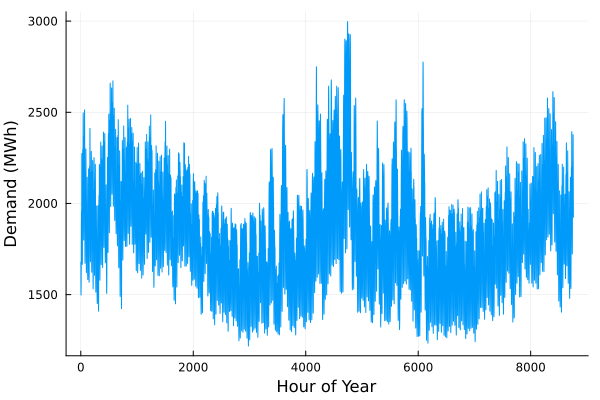

In [8]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [7]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

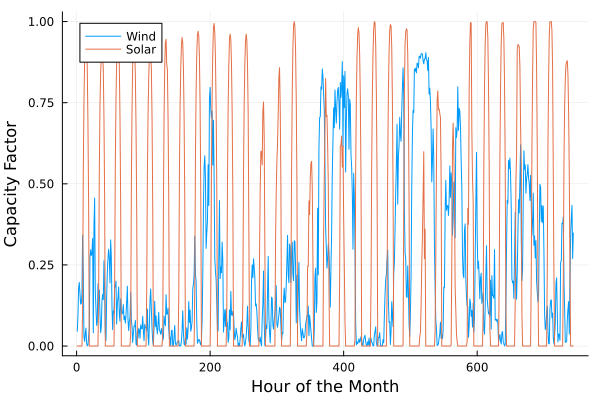

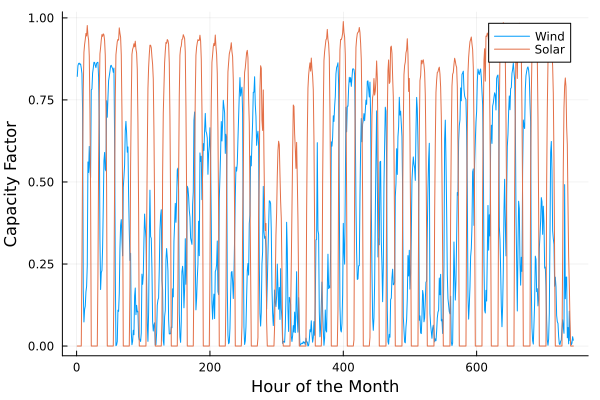

In [6]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

**In this problem**:

-   Formulate a linear program for this capacity expansion problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations).
-   Implement your linear program in `JuMP.jl`. Find the optimal
    solution. How much should the utility build of each type of
    generating plant? What will the total cost be? How much energy will
    be non-served?
-   What fraction of annual generation does each plant type produce? How
    does this compare to the breakdown of built capacity that you found
    in Problem 1.5? Do these results make sense given the generator
    data?
-   Make a plot of the electricity price in each hour. Discuss any
    trends that you see.

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

Step 1: Decision Variables
- $x_g$: installed capacity (MW) from each generator type g $\in$ G.
- $y_{g,t}$: production (MWh) from each generator type $g$ in hour $t \in T$
- $NSE_t$: non-served energy (MWh) in hour $t \in T$. 

Step 2: Objective Function

For this objective function, we are interested in minimizing the total cost of meeting the electricity demand over the entirety of $T$. There are three components to this:
- Fixed Costs: total installation cost for each generator type, calculated as $FixedCost_gx_g$ for all $g \in G$. This represents the capital cost of building the required generation capacity. 
- Variable Costs: the operational cost for each generator type, calculated as $VarCost_g * y_{g,t}$ for each generator $g$ at time period $t$. This captures the cost of generating power based on the operational costs of each generator. 
- Non-Served Energy Cost: A penalty cost for each unit of unmet demand, calculated as $NSECost * NSE_t$ for each period $t$. This penalizes instances where the demand is not met by available generation. 

Thus, the objective function can be expressed as:

$min_{x,y,NSE}Z = \sum_{g \in G} FixedCost_gx_g + \sum_{g \in G, t \in T} VarCost_g * y_{g,t} + \sum_{t \in T} NSECost * NSE_t$

Step 3: Constraints
- $\sum_{g \in G} y_{g,t} + NSE_t = d_t;$ $\forall t \in T$ (demand constraint)
- $y_{g,t} \leq x_g * CapacityFactor_{t,g};$ $\forall g \in G, \forall t \in T$ (capacity constraint)
- $x_g, y_{g,t}, NSE_t \geq 0;$ $\forall g \in G, \forall t \in T$ (non-negativity constraint)

In [12]:
# Create the model
model = Model(HiGHS.Optimizer)

# Define the sets and data
G = ["Geothermal", "Coal", "NG_CCGT", "NG_CT", "Wind", "Solar"]
T = 1:8760 
FixedCost = [450000, 220000, 82000, 65000, 91000, 70000]  # $/MW
VarCost = [0, 24, 30, 40, 0, 0]  # $/MWh
NSECost = 10000  # $/MWh

#Extract wind and solar capacity 
wind_capacity = cap_factor.Wind
solar_capacity = cap_factor.Solar

# Assign capacity factors
CapacityFactor[:,1] .= 0.85  # Geothermal (constant 85% capacity)
CapacityFactor[:,2] .= 1.0   # Coal (assumed full capacity)
CapacityFactor[:,3] .= 1.0   # NG_CCGT (assumed full capacity)
CapacityFactor[:,4] .= 1.0   # NG_CT (assumed full capacity)
CapacityFactor[:,5] .= wind_capacity  
CapacityFactor[:,6] .= solar_capacity 

# Decision variables
@variable(model, 0 <= x[g in 1:length(G)]) # Installed Capacity 
@variable(model, y[g in 1:length(G), t in T] >= 0)  # Power generated
@variable(model, NSE[t in T] >= 0)  # Non-served energy

# Objective function
@objective(model, Min, sum(FixedCost[g] .* x[g] for g in 1:length(G)) .+
                      sum(VarCost[g] .* y[g, t] for g in 1:length(G), t in T) .+
                      sum(NSECost .* NSE[t] for t in T))

#Constraints
for t in T
    @constraint(model, sum(y[:, t]) + NSE[t] == demand.Demand[t])
end

for g in 1:length(G) 
    for t in 1:length(T)
@constraint(model, y[g, t] <= x[g] * CapacityFactor[t,g]) 
    end
end 

# Solve the model
optimize!(model)

# Get results
installed_capacity = value.(x)
generated_power = value.(y)
nse = value.(NSE)
total_cost = objective_value(model)

# Display results
println("Optimal installed capacity (MW): ", installed_capacity)
println("Total cost: \$", round(total_cost, digits=2))
println("Total non-served energy (MWh): ", sum(nse))

Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 3e+03]
Presolving model
56856 rows, 56862 cols, 153048 nonzeros  0s
56856 rows, 56862 cols, 153048 nonzeros  0s
Presolve : Reductions: rows 56856(-4464); columns 56862(-4464); elements 153048(-8928)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(4.52383e+06) 0s
      41186     6.5428100839e+08 Pr: 3113(504028); Du: 0(8.93268e-08) 6s
      41973     6.5458487038e+08 Pr: 0(0); Du: 0(2.78952e-10) 7s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 41973
Objective value     :  6.5458487038e+08
HiGHS run time      :          6.81
Optimal installed capacity (MW): [0.0, 0.0, 1658.4514133074133, 879.7538120149645, 484.946

In [10]:
# Total generation for each plant type
total_generation = sum(y[g, t] for t in T, g in 1:length(G))

# Generation fraction per plant type
annual_generation = [sum(value(y[g, t]) for t in T) for g in 1:length(G)]
total_annual_generation = sum(annual_generation)
generation_fraction = annual_generation ./ total_annual_generation

# Display the results
println("Fraction of annual generation for each plant type:")
for g in 1:length(G)
    println(G[g], ": ", round(generation_fraction[g] * 100, digits=2), "%")
end

Fraction of annual generation for each plant type:
Geothermal: 0.0%
Coal: 0.0%
NG_CCGT: 52.89%
NG_CT: 2.75%
Wind: 8.68%
Solar: 35.68%


In [31]:
# Display installed capacity alongside generation fraction
println("\nComparison of Installed Capacity and Generation Fraction:")
for g in 1:length(G)
    println(G[g], ": Installed Capacity = ", installed_capacity[g], " MW, ",
            "Generation Fraction = ", round(generation_fraction[g] * 100, digits=2), "%")
end


Comparison of Installed Capacity and Generation Fraction:
Geothermal: Installed Capacity = 0.0 MW, Generation Fraction = 0.0%
Coal: Installed Capacity = 0.0 MW, Generation Fraction = 0.0%
NG_CCGT: Installed Capacity = 1658.4514133074133 MW, Generation Fraction = 52.89%
NG_CT: Installed Capacity = 879.7538120149645 MW, Generation Fraction = 2.75%
Wind: Installed Capacity = 484.946167110047 MW, Generation Fraction = 8.68%
Solar: Installed Capacity = 1957.6424239086684 MW, Generation Fraction = 35.68%


These results make sense when considering the fixed costs for each generator type. Geothermal ($\$450,000$) and Coal ($\$220,000$) have the highest fixed cost, so it would not be optimal to include them in the total generation fraction. When comparing NG_CCGT and NG_CT, NG_CCGT has a higher fixed cost ($\$82,000$) but lower varibale cost ($\$24$) and emissions ($.43$). Although NG_CT has a lower fixed cost ($\$65,000$), this difference is marginal compared to the other weighted downsides like higher variable cost and emissions. Thus, NG_CCGT will be produced more. When comaring wind and solar, both have no variable costs or emission. Solar has a lower fixed cost ($\$70,000$) than wind ($\$91,000$), so it is obvious it will be more optimal to produce more solar than wind.

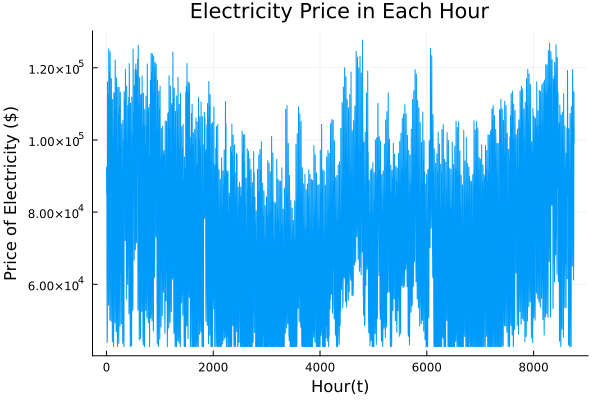

In [30]:
using Statistics

# Calculate variable hourly costs
var_costs = [sum(VarCost[g] * value(y[g, t]) for g in 1:length(G)) + NSECost * value(NSE[t]) for t in T]

# Calculate fixed hourly costs by dividing the fixed cost over all hours
fixed_costs = sum(FixedCost[g] * value(x[g]) / length(T) for g in 1:length(G))

# Total hourly cost is variable and fixed costs added 
total_costs = var_costs .+ fixed_costs

# Calculate interquartile range (IQR) for filtering outliers
Q1 = quantile(total_hourly_costs, 0.25)
Q3 = quantile(total_hourly_costs, 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter costs and time to exclude outliers
filtered_costs = total_hourly_costs[(total_costs .>= lower_bound) .& (total_costs .<= upper_bound)]
filtered_time = T[(total_costs .>= lower_bound) .& (total_costs .<= upper_bound)]

# Plot the filtered electricity prices over time
using Plots
plot(filtered_time, filtered_costs, xlabel = "Hour(t)", ylabel = "Price of Electricity (\$)", title = "Electricity Price in Each Hour", label = false)


One trend that can be inferred from this graph are seasonal trends. There appear to be distinct periods where the electricity price is higher on average, which could correspond to seasonal demand peaks. For instance, the price might be higher during extreme weather conditions in summer (air conditioning) and winter (heating).

Another trend are daily cycles. Although it’s not as clear at this scale, there may be smaller cyclical fluctuations within each day due to typical usage patterns (e.g., morning and evening peaks when people are most active). Zooming in on smaller segments, such as daily or weekly periods, might reveal these patterns more clearly. This is further reflected by the "spikeness" of the graph, which could represent these shorter-time cycles. 

### Problem 3 (10 points)

**This problem is only required for students in BEE 5750**.

The NY state legislature is considering enacting an annual
CO<sub>2</sub> limit, which for the utility would limit the emissions in
its footprint to 1.5 MtCO<sub>2</sub>/yr.

**In this problem**:

-   Reformulate your linear program from Problem 2 with any necessary
    changes to capture the CO<sub>2</sub> limit.
-   Implement the new optimization problem and find the optimal
    solution. How much should the utility build of each type of
    generating plant? What is different from your plan from Problem 1?
    Do these changes make sense?
-   What would the value to the utility be of allowing it to emit an
    additional 1000 tCO<sub>2</sub>/yr? An additional 5000?

## References

List any external references consulted, including classmates.